# Visualizations tutorial

This tutorial shows how to inspect a complete exception-rule triple using the visualization API. **CR** denotes a commonsense rule, **RR** a reference rule, and **ER** an exception rule. The examples use a classification model, but the plotting methods belong to the common base class and are also available for regression and survival models.

## Install dependencies

In [1]:
# %pip install matplotlib itables

## Load and prepare the dataset

The Mushroom dataset contains nominal attributes stored in ARFF format. Byte strings are decoded and missing values represented by `?` are replaced with `None`.

In [2]:
from pathlib import Path

import pandas as pd
from scipy.io import arff
from itables import show

from exception_rules.classification.algorithm import ExceptionRulesClassifier

df = pd.DataFrame(arff.loadarff(Path("mushroom.arff"))[0])
object_columns = df.select_dtypes(include=[object])
if not object_columns.empty:
    decoded = object_columns.stack().str.decode("utf-8").unstack()
    for column in decoded:
        df[column] = decoded[column].replace({"?": None})

X = df.drop(columns=["class"])
y = df["class"]
df.head()

,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


## Train the model and select an exception

Exception discovery must be enabled. We then select the first commonsense rule that has both a reference rule and an exception rule.

In [3]:
model = ExceptionRulesClassifier(
    mincov=5, induction_measure="c2", find_exceptions=True
).fit(X, y)

rule = next(
    candidate for candidate in model.ruleset.rules
    if candidate.reference_rule is not None and candidate.exception_rule is not None
)

print(f"CR: {rule}")
print(f"RR: {rule.reference_rule}")
print(f"ER: {rule.exception_rule}")

CR: IF gill-size = {n} THEN class = p (p=2224, n=288, P=3916, N=4208)
RR: IF spore-print-color = {h} THEN class = p (p=1584, n=48, P=3916, N=4208)
ER: IF gill-size = {n} AND spore-print-color = {h} THEN class = e (p=48, n=0, P=4208, N=3916)


## Covered examples

`get_covered_examples` returns the feature and target rows covered by a selected rule. `itables.show` renders the result as a searchable, sortable, paginated table. Replace `rule` with `rule.reference_rule` or `rule.exception_rule` to inspect RR or ER coverage.

In [4]:
covered_X, covered_y = model.get_covered_examples(rule.exception_rule)
covered_examples = pd.DataFrame(covered_X, columns=model.columns_names)
covered_examples[model.label_name] = covered_y
show(covered_examples, paging=True, pageLength=10, scrollX=True)

## Attribute distributions

Numeric attributes are displayed as histograms and nominal attributes as category-count bars. The colors compare examples covered by CR, RR, and ER. Use `all_attributes=False` to restrict the panels to attributes occurring in ER. Compact mode arranges the panels in a multi-column grid.

Matplotlib is building the font cache; this may take a moment.


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\dawid\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


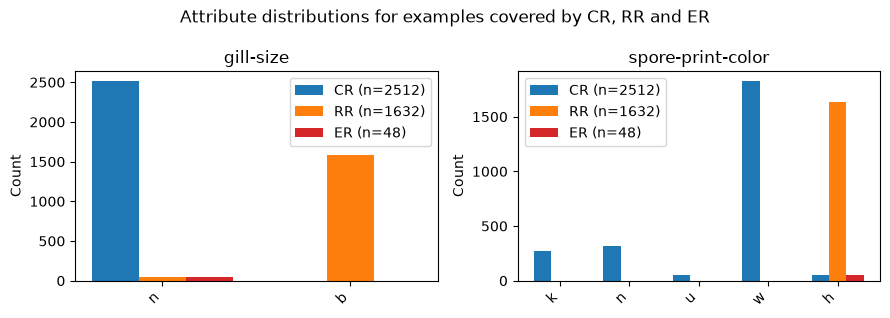

In [5]:
model.plot_covered_examples_distributions(rule, all_attributes=False, compact=True);

## PCA projection

PCA projects the selected attributes onto two unsupervised components. Separate ER points suggest a distinctive exception profile, while overlap indicates similarity. Axis labels report the proportion of variance retained by each component.

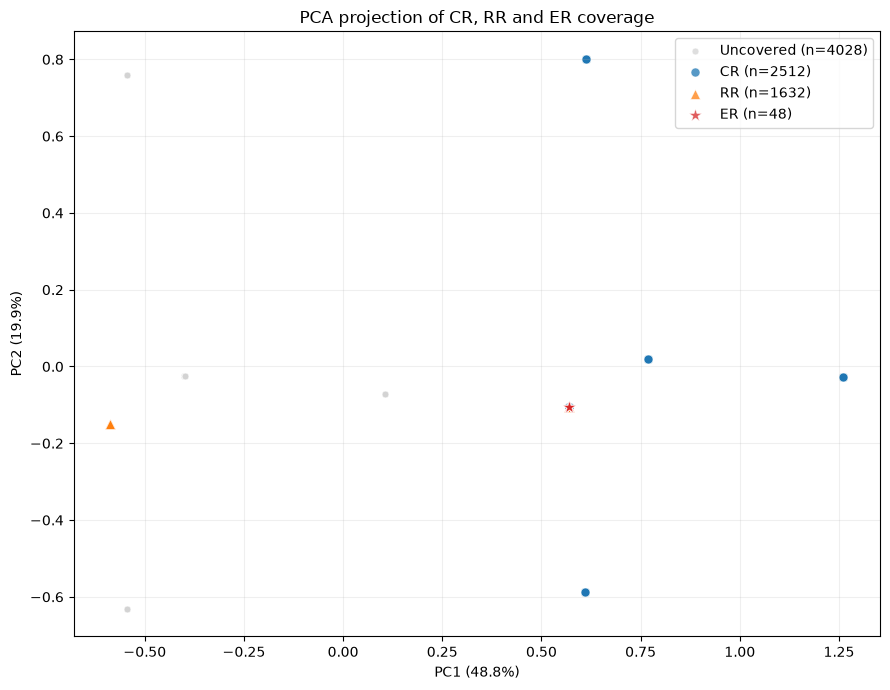

In [6]:
model.plot_rule_pca(rule, all_attributes=False);

## Supervised exception separation

LDA finds a one-dimensional direction that separates ER from non-ER examples. Little overlap between the density histograms indicates strong linear separation. Because the ER labels are used to construct this axis, treat the result as a training-data diagnostic rather than independent validation.

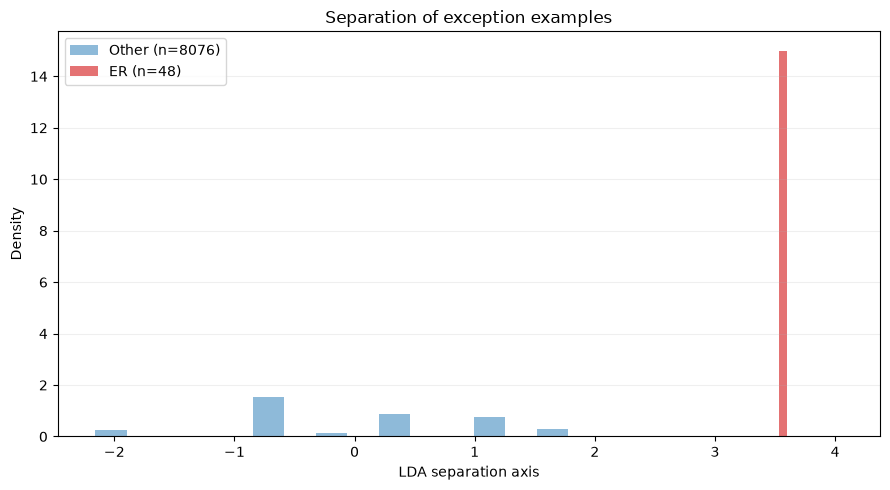

In [7]:
model.plot_exception_separation(rule, all_attributes=False, bins=15);

## Exception neighborhood

This visualization compares ER with CR excluding ER and RR excluding ER. Numeric features use empirical cumulative distribution functions, while nominal features use category proportions. Larger differences identify attributes that distinguish the exception from its immediate context.

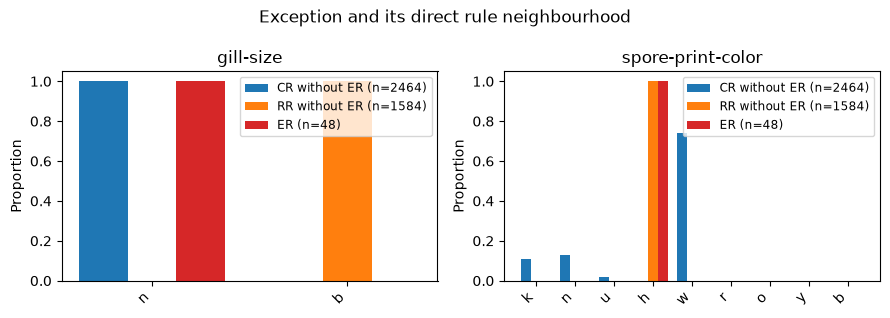

In [8]:
model.plot_exception_neighborhood(rule, all_attributes=False);

## Parallel coordinates

Each line represents one covered example across transformed feature axes. A consistent ER pattern that differs from CR and RR reveals a multidimensional exception profile. Nominal attributes are expanded into one-hot columns.

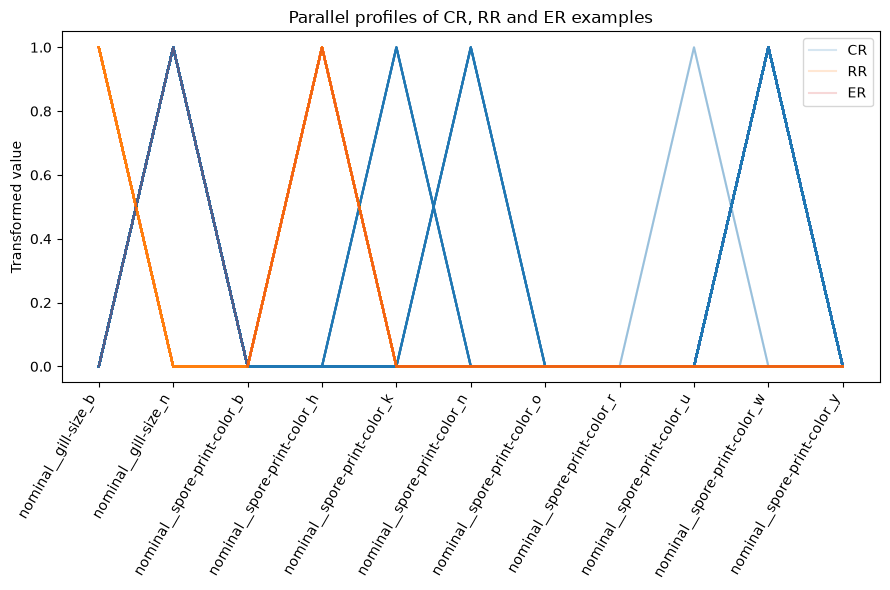

In [9]:
model.plot_rule_parallel_coordinates(rule, all_attributes=False);

## Numeric boxplots

Boxplots compare medians, quartiles, spread, and outliers for numerical ER attributes. When the selected attributes are all nominal, the method displays an explanatory message and recommends an appropriate categorical visualization.

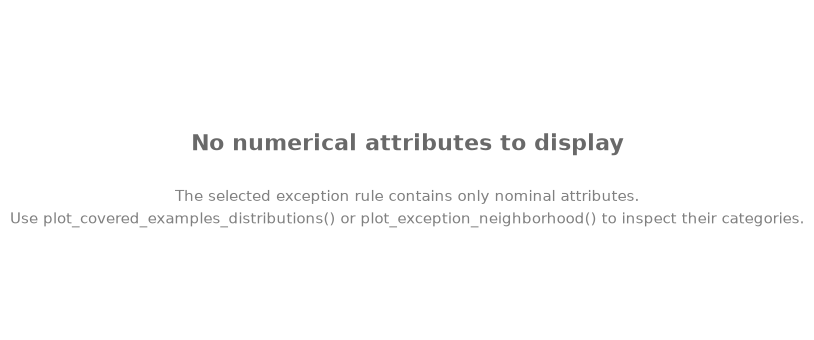

In [10]:
model.plot_rule_boxplots(rule, all_attributes=False);

## Attribute-profile heatmap

Rows are covered examples ordered from CR through RR to ER, and columns are encoded features. Uniform color blocks indicate consistent profiles; an abrupt change in the ER rows identifies features associated with the exception.

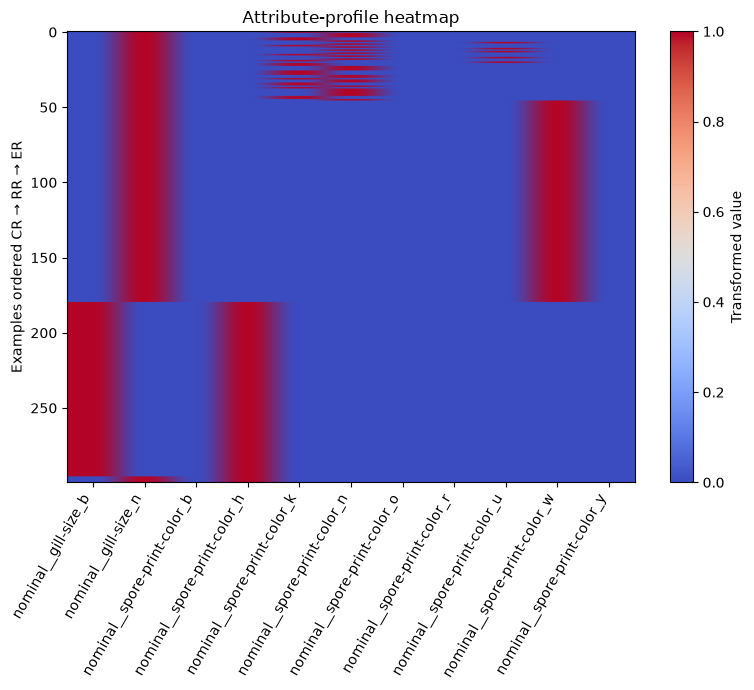

In [11]:
model.plot_rule_heatmap(rule, all_attributes=False);

## Coverage matrix

Each row is an example and the three columns indicate CR, RR, and ER coverage. Rows are sorted by their Boolean coverage pattern. This plot makes nesting and unexpected coverage relationships visible.

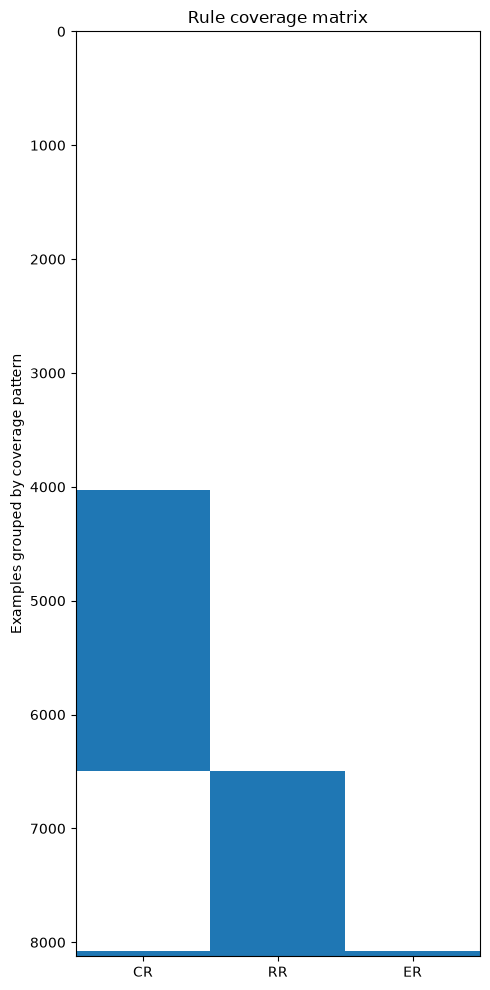

In [12]:
model.plot_rule_coverage_matrix(rule);

## Coverage intersections

The UpSet-style chart reports the exact sizes of all CR–RR–ER intersections. The bars show intersection counts and the dot matrix identifies the participating rules. It is a precise summary of exclusive and shared coverage.

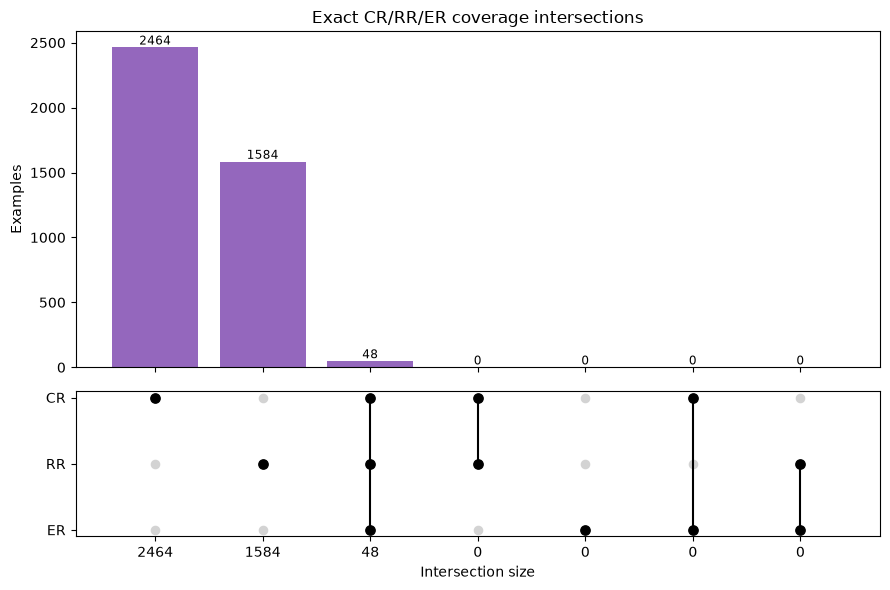

In [13]:
model.plot_rule_coverage_intersections(rule);

## Summary

Use distribution and neighborhood plots to understand individual attributes, PCA and LDA to assess separation, parallel coordinates and heatmaps to inspect multidimensional profiles, and coverage plots to verify the logical relationship between CR, RR, and ER. No single plot is conclusive; the views are designed to complement one another.